## Business Understanding

Цель: Сделать новую версию модели машинного обучения с большей выборкой и лучшими features для достижения метрики R2 > 90%

## Data Understanding

### imports

In [378]:
from idlelib.replace import replace
from random import Random

import pandas as pd
import numpy as np
from plotly.graph_objs.layout.shape import label
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sqlalchemy.dialects.mssql.information_schema import columns

# глобальная настройка отображения
pd.set_option('display.float_format', '{:.3f}'.format)

In [379]:
data_file = pd.ExcelFile('data/data.xlsx')

print(data_file.sheet_names)

['so', 'am_01_26', 'am_05_25', 'am_09_24', 'ms_total', 'ms_in_dm', 'ms_by_cityes', 'ms_by_regions', 'ms_dm_by_cityes', 'osa_26', 'osa_06_12_2025', 'osa_12_24_05_25']


In [380]:
df_so = pd.read_excel('data/data.xlsx', sheet_name='so')
df_am_01_26 = pd.read_excel('data/data.xlsx', sheet_name='am_01_26')
df_am_05_25 = pd.read_excel('data/data.xlsx', sheet_name='am_05_25')
df_am_09_24 = pd.read_excel('data/data.xlsx', sheet_name='am_09_24')
df_ms_total = pd.read_excel('data/data.xlsx', sheet_name='ms_total')
df_ms_in_dm_total = pd.read_excel('data/data.xlsx', sheet_name='ms_in_dm')
df_ms_by_cities = pd.read_excel('data/data.xlsx', sheet_name='ms_by_cityes')
df_ms_by_regions = pd.read_excel('data/data.xlsx', sheet_name='ms_by_regions')
df_ms_dm_by_cities = pd.read_excel('data/data.xlsx', sheet_name='ms_dm_by_cityes')
df_osa_26 = pd.read_excel('data/data.xlsx', sheet_name='osa_26')
df_osa_06_12_25 = pd.read_excel('data/data.xlsx', sheet_name='osa_06_12_2025')
df_osa_12_24_05_25 = pd.read_excel('data/data.xlsx', sheet_name='osa_12_24_05_25')

In [381]:
df_so = df_so.rename(columns={
    'SO Код точки': 'id',
    'SO Address': 'address',
    'SO Город': 'city',
    'SO Область': 'micro_region',
    'SO Регион RUS': 'region',
    'Cluster3 From Chain': 'cluster',
    'Cluster4 From Chain': 'cluster_extra',
    'Год': 'year',
    'Месяц': 'month',
    'Bebelac Cereals': 'so_bebelac_cereals',
    'Bebelac Milks': 'so_bebelac_milks',
    'Malyotka Cereals': 'so_malyotka_cereals',
    'Malyoutka Foods': 'so_malyotka_foods',
    'Malyotka Milks': 'so_malyotka_milks',
    'Malysh Milks': 'so_malysh_milks',
    'Nutricia Medical Milks': 'so_nutricia_medical_milks',
    'Nutricia Medical Paed': 'so_nutricia_medical_paed',
    'Nutricia Medical Tube': 'so_nutricia_medical_tube',
    'Nutrilon Cereals': 'so_nutricia_cereals',
    'Nutrilon Milks': 'so_nutricia_medical_milks',
    'Grand Total': 'so_total',
})

df_so.head(3)

,id,address,city,micro_region,region,cluster,cluster_extra,year,month,so_bebelac_cereals,...,so_malyotka_cereals,so_malyotka_foods,so_malyotka_milks,so_malysh_milks,so_nutricia_medical_milks,so_nutricia_medical_paed,so_nutricia_medical_tube,so_nutricia_cereals,so_nutricia_medical_milks,so_total
0,DM__396,РЦ КРЁКШИНО Интернет-магазин,Балашиха,Московская обл,Москва,NaN,NaN,2026,3,NaN,...,75573.000,NaN,2789515.580,243633.000,3229503.000,95329.000,33690.000,1282534.000,24786976.000,32663055.080
1,DM__396,РЦ КРЁКШИНО Интернет-магазин,Балашиха,Московская обл,Москва,NaN,NaN,2026,4,NaN,...,90894.000,NaN,2688783.230,198786.000,927578.000,81639.000,52781.000,1132470.000,24475620.500,29851497.730
2,DM__396,РЦ КРЁКШИНО Интернет-магазин,Балашиха,Московская обл,Москва,NaN,NaN,2026,2,NaN,...,70425.000,NaN,2502833.520,182652.000,3195647.500,55680.000,86471.000,1021791.000,19669703.000,26936333.020


### fcs

In [382]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def print_info(df, name: str):
    print(f'{"*"*20}')
    print(f'{"="*5} РАЗМЕР {name} {"="*5}')
    print(df.shape)
    print(f'{"="*5} ТИП ДАННЫХ {name} {"="*5}')
    print(df.dtypes)
    print(f'{"="*5} ПРОПУСКИ {name} {"="*5}')
    print(df.isnull().sum())
    print(f'{"="*5} СТАТИСТИКА {name} {"="*5}')
    stats = df.describe()
    stats = stats.map(lambda x: f'{x:.2f}' if isinstance(x, (float, int)) else str(x))
    print(stats)
    print(f'{"="*5} ПЕРВЫЕ 5 СТРОК {name} {"="*5}')
    print(df.head())
    print(f'{"*"*20}')

def evaluate_model(y_true, y_pred, dataset_name):
  mse = mean_squared_error(y_true, y_pred)
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true, y_pred)

  print(f'\n---Метрика для {dataset_name} ---')
  print(f'MAE (Средняя абсолютная ошибка): {mae:.2f}')
  print(f'MSE (Средняя квадратичная ошибка): {mse:.2f}')
  print(f'RMSE (Корень из MSE): {rmse:.2f}')
  print(f'R2-score (Коэффициент детерминации): {r2:.4f}')

  return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}


def get_sku_counts_for_cluster(df_matrix, cluster_name):
    cluster_mask = df_matrix[cluster_name] == 1
    return {
        'milks_sku_count_in_matrix': len(df_matrix[cluster_mask & (df_matrix['product_category'] == 'Смеси')]),
        'cereals_sku_count_in_matrix': len(df_matrix[cluster_mask & (df_matrix['product_category'] == 'Каши')]),
        'nutrilon_milks_sku_count_in_matrix': len(df_matrix[cluster_mask & (df_matrix['brand'] == 'Nutrilon/Neokate/Nutridrink') & (df_matrix['product_category'] == 'Смеси')]),
        'bebelac_milks_sku_count_in_matrix': len(df_matrix[cluster_mask & (df_matrix['brand'] == 'Bebelac') & (df_matrix['product_category'] == 'Смеси')]),
        'malutka_milks_sku_count_in_matrix': len(df_matrix[cluster_mask & (df_matrix['brand'] == 'Малютка') & (df_matrix['product_category'] == 'Смеси')]),
        'malysh_milks_sku_count_in_matrix': len(df_matrix[cluster_mask & (df_matrix['brand'] == 'МАЛЫШ') & (df_matrix['product_category'] == 'Смеси')]),
        'nutrilon_cereals_sku_count_in_matrix': len(df_matrix[cluster_mask & (df_matrix['brand'] == 'Nutrilon/Neokate/Nutridrink') & (df_matrix['product_category'] == 'Каши')]),
        'malutka_cereals_sku_count_in_matrix': len(df_matrix[cluster_mask & (df_matrix['brand'] == 'Малютка') & (df_matrix['product_category'] == 'Каши')]),
    }

def clean_string(string):
    string = str(string)
    string = string.lower()
    string = string.strip()
    while '  ' in string:
        string = string.replace('  ', ' ')
    return string

def extract_year_month(period):
    year, month = period.split('_')
    return int(year), int(month)

def get_am(am_df):
    am_df = am_df.rename(columns={
        'Название подотдела товаров': 'category',
        'Название бренда': 'brand'
    })
    am_df = am_df.groupby(['category', 'brand']).sum().reset_index()
    am_df['category_brand'] = (am_df['category'] +
                                                        '_' +
                                                       am_df['brand'])

    am_df = am_df.drop(['category', 'brand'], axis=1)
    am_df = am_df.set_index('category_brand')
    am_df = am_df.T
    am_df['am_sku_milks'] = (
        am_df['Смеси_Nutrilon/Neokate/Nutridrink'] +
        am_df['Смеси_МАЛЫШ'] +
        am_df['Смеси_Малютка'] +
        am_df['Смеси_Bebelac']
    )

    am_df['am_sku_cereals'] = (
        am_df['Каши_Nutrilon/Neokate/Nutridrink'] +
        am_df['Каши_Малютка']
    )

    am_df = am_df.rename(columns={
        'Смеси_Nutrilon/Neokate/Nutridrink': 'nutrilon_neokate_nutridrink_milk_am_sku_count',
        'Смеси_Bebelac': 'bebelac_milk_am_sku_count',
        'Каши_Bebelac': 'bebelac_cereals_am_sku_count',
        'Смеси_МАЛЫШ': 'malysh_milk_am_sku_count',
        'Смеси_Малютка': 'malytka_milk_am_sku_count',
        'Каши_Nutrilon/Neokate/Nutridrink': 'nutrilon_cereal_am_sku_count',
        'Каши_Малютка': 'malytka_cereal_am_sku_count',
    })

    am_df = (
        am_df
        .rename_axis('cluster')
        .reset_index()
    )

    if 'category_brand' in am_df.columns:
        am_df = am_df.drop('category_brand', axis=1)

    am_df['cluster'] = am_df['cluster'].apply(clean_string)

    # print(am_df.head(3))
    # print("\nКолонки:", am_df.columns.tolist())

    return am_df


def create_osa_feature(row):
    if isinstance(row['Код ТТ'], str) and 'Total' in row['Код ТТ']:
        value_name = 'osa_total'

    elif 'Total' in row['Продуктовая категория']:
        value_name = f'osa_{clean_string(row['Продуктовая категория']).replace(' ', '_')}'

    else:
        value_name = f'osa_{clean_string(row['Продуктовая категория'])}_{clean_string(row['Бренд'])}'

    return value_name.replace(' ', '_')


def transform_ms_df(df, target_feature_name):
    df_long = df.melt(
        id_vars=['SO City', 'Company'],
        var_name='period',
        value_name='ms',
    )

    df_long['year'] = df_long['period'].str.split('_').str[0].astype(int)
    df_long['month'] = df_long['period'].str.split('_').str[1].astype(int)

    df_long = df_long.dropna(subset=['ms'])

    df_long = df_long[['SO City', 'year', 'month', 'ms']]

    df_long = df_long.rename(columns={'SO City': 'city', 'ms': target_feature_name})

    return df_long

### data visualisation

In [383]:
print_info(df_so, 'so')

********************
===== РАЗМЕР so =====
(49643, 21)
===== ТИП ДАННЫХ so =====
id                            object
address                       object
city                          object
micro_region                  object
region                        object
cluster                       object
cluster_extra                 object
year                           int64
month                          int64
so_bebelac_cereals           float64
so_bebelac_milks             float64
so_malyotka_cereals          float64
so_malyotka_foods            float64
so_malyotka_milks            float64
so_malysh_milks              float64
so_nutricia_medical_milks    float64
so_nutricia_medical_paed     float64
so_nutricia_medical_tube     float64
so_nutricia_cereals          float64
so_nutricia_medical_milks    float64
so_total                     float64
dtype: object
===== ПРОПУСКИ so =====
id                               0
address                          0
city                             0

In [384]:
# удаляем все отрицательные значения Grand Total
df_so = df_so[df_so['so_total'] > 0]

df_so['so_total'].describe()

count      49630.000
mean      459087.766
std       562917.903
min           38.500
25%       193181.775
50%       368336.800
75%       584693.000
max     32663055.080
Name: so_total, dtype: float64

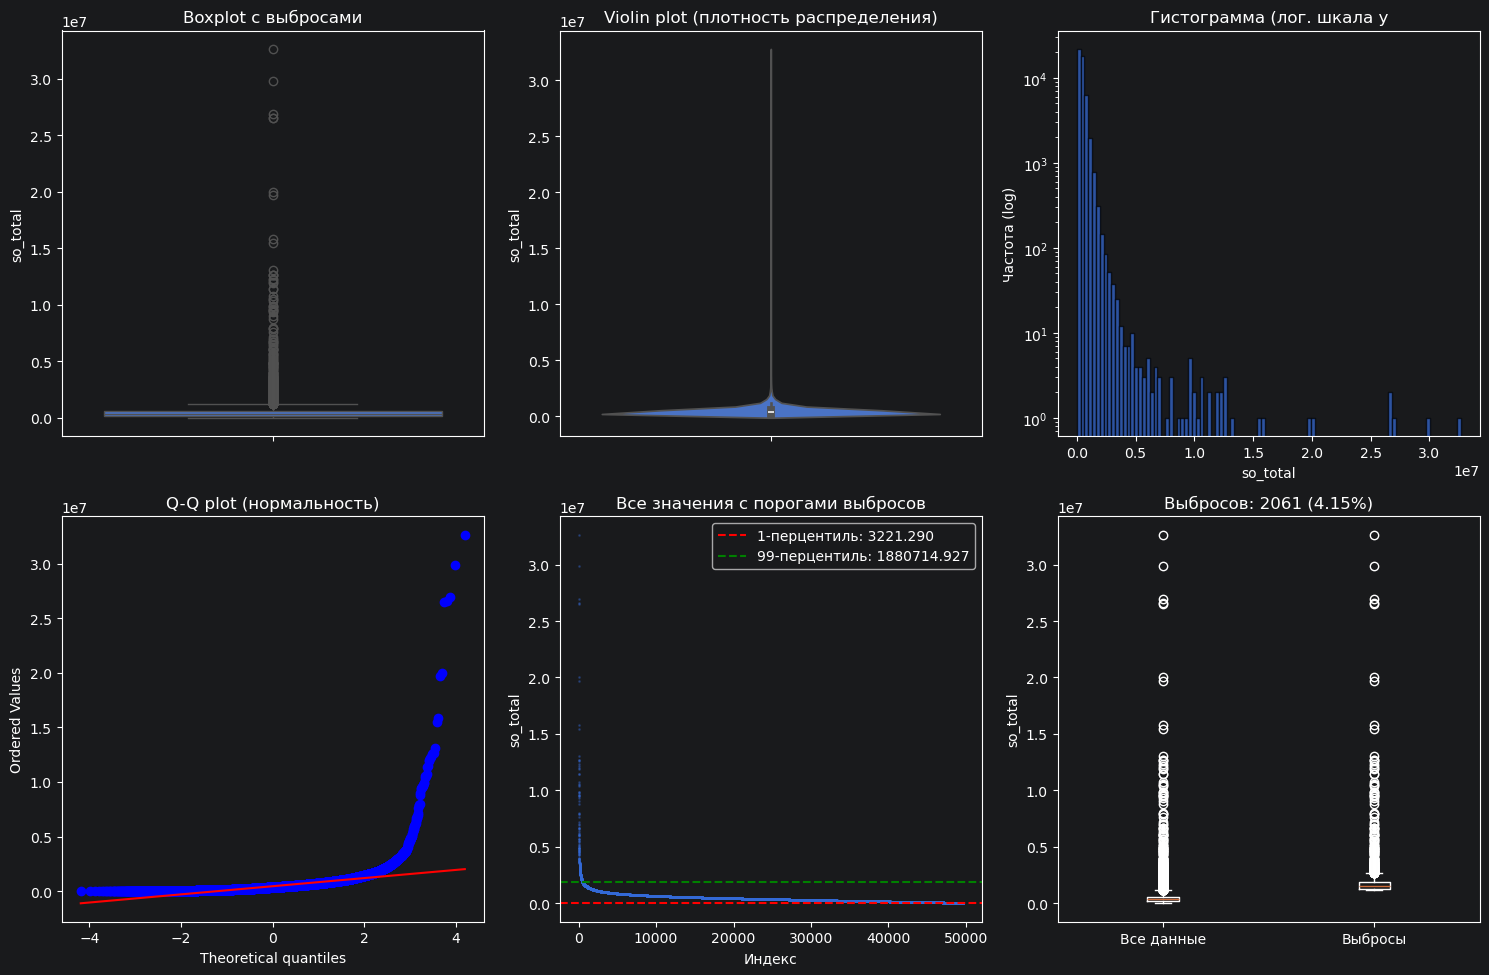

In [385]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Boxplot с выбросами
sns.boxplot(y=df_so['so_total'], ax=axes[0, 0], showfliers=True)
axes[0, 0].set_title('Boxplot с выбросами')
axes[0, 0].set_ylabel('so_total')

# 2. Violin plot
sns.violinplot(y=df_so['so_total'], ax=axes[0, 1])
axes[0,1].set_title('Violin plot (плотность распределения)')

# 3. Гистограмма с логарифмической шкалой
axes[0,2].hist(df_so['so_total'], bins=100, edgecolor='black', alpha=0.7)
axes[0,2].set_yscale('log')
axes[0,2].set_title('Гистограмма (лог. шкала y')
axes[0,2].set_xlabel('so_total')
axes[0,2].set_ylabel('Частота (log)')

# 4. Q-Q plot для проверки нормальности
stats.probplot(df_so['so_total'].dropna(), dist='norm', plot=axes[1, 0])
axes[1,0].set_title('Q-Q plot (нормальность)')

# 5. График 'квантиль-значение' для выбросов
q_low = df_so['so_total'].quantile(0.01)
q_high = df_so['so_total'].quantile(0.99)

axes[1,1].scatter(range(len(df_so['so_total'])), df_so['so_total'], alpha=0.3, s=1)
axes[1,1].axhline(y=q_low, color='r', linestyle='--', label=f'1-перцентиль: {q_low:.3f}')
axes[1,1].axhline(y=q_high, color='g', linestyle='--', label=f'99-перцентиль: {q_high:.3f}')
axes[1,1].set_title('Все значения с порогами выбросов')
axes[1,1].set_xlabel('Индекс')
axes[1,1].set_ylabel('so_total')
axes[1,1].legend()

# 6. Статистика выбросов по IQR
Q1 = df_so['so_total'].quantile(0.25)
Q3 = df_so['so_total'].quantile(0.75)
IQR = Q3 - Q1
lower_band = Q1 -1.5 * IQR
upper_band = Q3 + 1.5 * IQR

outliers = df_so['so_total'][(df_so['so_total'] < lower_band) | (df_so['so_total'] > upper_band)]
axes[1,2].boxplot([df_so['so_total'], outliers.dropna()], tick_labels=['Все данные', 'Выбросы'])
axes[1,2].set_title(f'Выбросов: {len(outliers)} ({len(outliers)/len(df_so)*100:.2f}%)')
axes[1,2].set_ylabel('so_total')

plt.tight_layout()

In [386]:
# Дополнительная числовая статистика выбросов
print("="*50)
print("Статистика по выбросам (IQR метод):")
print(f'Q1 (25%): {Q1:.4f}')
print(f'Q1 (75%): {Q3:.4f}')
print(f'IQR: {IQR:.4f}')
print(f'Нижняя граница: {lower_band:.4f}')
print(f'Верхняя граница: {upper_band:.4f}')
print(f'Количество выбросов: {len(outliers)} (доля: {len(outliers)/len(df_so)*100:.2f}%)')
print(f'Мин значение: {df_so['so_total'].min():.4f}')
print(f'Макс значение: {df_so['so_total'].max():.4f}')
print(f'Количество отрицательных значений: {len(df_so['so_total'][df_so['so_total'] < 0])}, '
      f'(доля: {len(df_so['so_total'][df_so['so_total'] < 0])/len(df_so['so_total'])*100:.2f}%)')
print(f'Количество нулевых значений: {len(df_so['so_total'][df_so['so_total'] == 0])}, '
      f'(доля: {len(df_so['so_total'][df_so['so_total'] == 0])/len(df_so['so_total'])*100:.2f}%)')
print(f'Количество значений более 2 000 000: {len(df_so['so_total'][df_so['so_total'] > 2000000])} , '
      f'(доля: {len(df_so['so_total'][df_so['so_total'] > 2000000])/len(df_so['so_total'])*100:.2f}%)')
print('='*50)

Статистика по выбросам (IQR метод):
Q1 (25%): 193181.7750
Q1 (75%): 584693.0000
IQR: 391511.2250
Нижняя граница: -394085.0625
Верхняя граница: 1171959.8375
Количество выбросов: 2061 (доля: 4.15%)
Мин значение: 38.5000
Макс значение: 32663055.0800
Количество отрицательных значений: 0, (доля: 0.00%)
Количество нулевых значений: 0, (доля: 0.00%)
Количество значений более 2 000 000: 419 , (доля: 0.84%)


## Data preparation

In [387]:
# применяем только к верхней границе
df_so = df_so[df_so['so_total'] < upper_band]

df_so['so_total'].describe()

count     47569.000
mean     395077.188
std      256798.602
min          38.500
25%      186481.000
50%      353328.400
75%      550412.340
max     1171800.370
Name: so_total, dtype: float64

#### AM data adding

In [388]:
# форматируем название кластеров
df_so['cluster'] = df_so['cluster'].apply(clean_string)
df_so['cluster_extra'] = df_so['cluster_extra'].apply(clean_string)
print(df_so.head())

           id                                            address       city  \
2061  DM__428  г. Улан-Удэ, Жердева, д. 136/1, ТЦ «People Par...   Улан-Удэ   
2062  DM__137  г. Астрахань "Ярмарка" № 163, Вокзальная площа...  Астрахань   
2063  DM__736                 Находка, проспект Мира, 1П, 2 этаж    Находка   
2064  DM__137  г. Астрахань "Ярмарка" № 163, Вокзальная площа...  Астрахань   
2065  DM__338                         Г. КИРОВ, ЛЕНИНА УЛ. Д.169      Киров   

          micro_region  region     cluster cluster_extra  year  month  \
2061      Бурятия Респ  Сибирь   кластер 1     кластер 1  2023      7   
2062  Астраханская обл      Юг   кластер 4     кластер 4  2023      6   
2063   Приморский край  Сибирь   кластер 2     кластер 2  2023      4   
2064  Астраханская обл      Юг   кластер 4     кластер 4  2024      2   
2065     Кировская обл   Волга  кластер 2+    кластер 2+  2023      9   

      so_bebelac_cereals  ...  so_malyotka_cereals  so_malyotka_foods  \
2061         

In [389]:
# объединяем с главным df
am_26 = get_am(df_am_01_26)
am_05_25 = get_am(df_am_05_25)
am_09_24 = get_am(df_am_09_24)

# Объединяем по одному с проверкой
df_temp = pd.DataFrame()

# создаем маски условий
mask_26 = df_so['year'] == 26
mask_25 = (df_so['year'] == 25) & (df_so['month'] >= 5)
mask_24 = ~(mask_26 & mask_25)

# Добавляем первый
df_26 = df_so[mask_26].merge(am_26, how='left', on='cluster')
df_26 = df_26.loc[:, ~df_26.columns.duplicated()]
df_temp = pd.concat([df_temp, df_26], ignore_index=True)

# Добавляем второй
df_25 = df_so[mask_25].merge(am_05_25, how='left', on='cluster')
df_25 = df_25.loc[:, ~df_25.columns.duplicated()]
df_temp = pd.concat([df_temp, df_25], ignore_index=True)

# Добавляем третий
df_24 = df_so[mask_24].merge(am_09_24, how='left', on='cluster')
df_24 = df_24.loc[:, ~df_24.columns.duplicated()]
df_temp = pd.concat([df_temp, df_24], ignore_index=True)

df_so_main = df_temp

print(set(df_so['cluster'].unique()) - set(df_so_main['cluster'].unique()))

print(df_so_main.shape)

set()
(47569, 29)


#### OSA data adding

In [390]:
# обработка AM df
df_osa_26['group'] = df_osa_26.apply(create_osa_feature, axis=1)
df_osa_06_12_25['group'] = df_osa_06_12_25.apply(create_osa_feature, axis=1)
df_osa_12_24_05_25['group'] = df_osa_12_24_05_25.apply(create_osa_feature, axis=1)

df_osa_26 = df_osa_26.drop(columns=['Продуктовая категория', 'Бренд'])
df_osa_06_12_25 = df_osa_06_12_25.drop(columns=['Продуктовая категория', 'Бренд'])
df_osa_12_24_05_25 = df_osa_12_24_05_25.drop(columns=['Продуктовая категория', 'Бренд'])

df_osa_26['Код ТТ'] = df_osa_26['Код ТТ'].apply(lambda x: str(x).replace('Total', '').strip() if pd.notna(x) else x)
df_osa_06_12_25['Код ТТ'] = df_osa_06_12_25['Код ТТ'].apply(lambda x: str(x).replace('Total', '').strip() if pd.notna(x) else x)
df_osa_12_24_05_25['Код ТТ'] = df_osa_12_24_05_25['Код ТТ'].apply(lambda x: str(x).replace('Total', '').strip() if pd.notna(x) else x)

print(df_osa_26.head(15))
print(df_osa_06_12_25.head(15))
print(df_osa_12_24_05_25.head(15))

      Код ТТ    01    02    03    04    05                       group
0     DM__10 1.000 1.000 0.909 0.978 1.000        osa_cereals_malyotka
1     DM__10 0.978 1.000 1.000 0.989 1.000        osa_cereals_nutrilon
2     DM__10 0.986 1.000 0.970 0.985 1.000           osa_cereals_total
3     DM__10 1.000 1.000 1.000 1.000 1.000           osa_milks_bebelac
4     DM__10 0.917 0.917 0.955 0.972 0.950          osa_milks_malyotka
5     DM__10 1.000 1.000 1.000 1.000 1.000            osa_milks_malysh
6     DM__10 0.926 1.000 0.879 0.111 0.833  osa_milks_nutricia_medical
7     DM__10 0.923 0.983 0.997 1.000 0.990          osa_milks_nutrilon
8     DM__10 0.930 0.969 0.980 0.939 0.971             osa_milks_total
9     DM__10 1.000 1.000 1.000 1.000 1.000   osa_paed_nutricia_medical
10    DM__10 1.000 1.000 1.000 1.000 1.000              osa_paed_total
11    DM__10 0.944 0.977 0.978 0.950 0.978                   osa_total
12  DM__1000 1.000 1.000 0.873 1.000 1.000        osa_cereals_malyotka
13  DM

In [391]:
# трансформируем df
def transform_osa_df(df):
    df = df.copy()

    duplicates = df.duplicated(subset=['Код ТТ', 'group']).sum()
    if duplicates > 0:
        print(f"Найдено {duplicates} дубликатов. Удаляем...")
        df = df.drop_duplicates(subset=['Код ТТ', 'group'], keep='first')

    df_melted = df.melt(
        id_vars=['Код ТТ', 'group'],
        var_name='month',
        value_name='osa',
    )

    df_result = df_melted.pivot(
        index= ['Код ТТ', 'month'],
        columns='group',
        values='osa',
    ).reset_index()

    df_result = df_result.rename(columns={
        'Код ТТ': 'id'
    })

    df_result['month'] = df_result['month'].astype(int)

    print(df_result.head())

    return df_result

df_osa_26_transformed = transform_osa_df(df_osa_26)
df_osa_06_12_transformed = transform_osa_df(df_osa_06_12_25)
df_osa_12_24_05_25_transformed = transform_osa_df(df_osa_12_24_05_25)


group      id  month  osa_cereals_malyotka  osa_cereals_nutrilon  \
0      DM__10      1                 1.000                 0.978   
1      DM__10      2                 1.000                 1.000   
2      DM__10      3                 0.909                 1.000   
3      DM__10      4                 0.978                 0.989   
4      DM__10      5                 1.000                 1.000   

group  osa_cereals_total  osa_milks_bebelac  osa_milks_malyotka  \
0                  0.986              1.000               0.917   
1                  1.000              1.000               0.917   
2                  0.970              1.000               0.955   
3                  0.985              1.000               0.972   
4                  1.000              1.000               0.950   

group  osa_milks_malysh  osa_milks_nutricia_medical  osa_milks_nutrilon  \
0                 1.000                       0.926               0.923   
1                 1.000               

In [392]:
# мерджим вместе с основным df
# создаем маски для корректной фильтрации объединения
osa_mask_26 = df_so_main['year'] == 2026
osa_mask_25 = (df_so_main['year'] == 2025) & (df_so_main['month'] >= 6)
osa_mask_24 = ((df_so_main['year'] == 2025) & (df_so_main['month'] < 6)) | ((df_so_main['year'] == 2024) & (df_so_main['month'] == 12))

df_temp = pd.DataFrame()

df_so_with_osa_26 = df_so_main[osa_mask_26].merge(df_osa_26_transformed, how='left', left_on=['id', 'month'], right_on=['id', 'month'])
df_so_with_osa_26 = df_so_with_osa_26.loc[:, ~df_so_with_osa_26.columns.duplicated()]
df_temp = pd.concat([df_temp, df_so_with_osa_26], ignore_index=True)

df_so_with_osa_25 = df_so_main[osa_mask_25].merge(df_osa_06_12_transformed, how='left', left_on=['id', 'month'], right_on=['id', 'month'])
df_so_with_osa_25 = df_so_with_osa_25.loc[:, ~df_so_with_osa_25.columns.duplicated()]
df_temp = pd.concat([df_temp, df_so_with_osa_25], ignore_index=True)

df_so_with_osa_24 = df_so_main[osa_mask_24].merge(df_osa_12_24_05_25_transformed, how='left', left_on=['id', 'month'], right_on=['id', 'month'])
df_so_with_osa_24 = df_so_with_osa_24.loc[:, ~df_so_with_osa_24.columns.duplicated()]
df_temp = pd.concat([df_temp, df_so_with_osa_24], ignore_index=True)

df_so_main_with_am_osa = df_temp

print(df_so_main_with_am_osa.shape)
print(df_so_main_with_am_osa['year'].unique())


(22022, 41)
[2026 2025 2024]


In [393]:
print(df_so_main_with_am_osa.columns.tolist())

['id', 'address', 'city', 'micro_region', 'region', 'cluster', 'cluster_extra', 'year', 'month', 'so_bebelac_cereals', 'so_bebelac_milks', 'so_malyotka_cereals', 'so_malyotka_foods', 'so_malyotka_milks', 'so_malysh_milks', 'so_nutricia_medical_milks', 'so_nutricia_medical_paed', 'so_nutricia_medical_tube', 'so_nutricia_cereals', 'so_total', 'nutrilon_cereal_am_sku_count', 'malytka_cereal_am_sku_count', 'bebelac_milk_am_sku_count', 'nutrilon_neokate_nutridrink_milk_am_sku_count', 'malysh_milk_am_sku_count', 'malytka_milk_am_sku_count', 'am_sku_milks', 'am_sku_cereals', 'bebelac_cereals_am_sku_count', 'osa_cereals_malyotka', 'osa_cereals_nutrilon', 'osa_cereals_total', 'osa_milks_bebelac', 'osa_milks_malyotka', 'osa_milks_malysh', 'osa_milks_nutricia_medical', 'osa_milks_nutrilon', 'osa_milks_total', 'osa_paed_nutricia_medical', 'osa_paed_total', 'osa_total']


In [394]:
result = {}

df_for_corr = df_so_main_with_am_osa[df_so_main_with_am_osa['osa_total'].notna()]

numeric_cols = ['month', 'nutrilon_cereal_am_sku_count', 'malytka_cereal_am_sku_count', 'bebelac_milk_am_sku_count', 'nutrilon_neokate_nutridrink_milk_am_sku_count', 'malysh_milk_am_sku_count', 'malytka_milk_am_sku_count', 'am_sku_milks', 'am_sku_cereals', 'bebelac_cereals_am_sku_count', 'osa_cereals_malyotka', 'osa_cereals_nutrilon', 'osa_cereals_total', 'osa_milks_bebelac', 'osa_milks_malyotka', 'osa_milks_malysh', 'osa_milks_nutricia_medical', 'osa_milks_nutrilon', 'osa_milks_total', 'osa_paed_nutricia_medical', 'osa_paed_total', 'osa_total', 'so_total']

correlations = df_for_corr[numeric_cols].corr()['so_total'].sort_values(ascending=False)

top_corr = correlations[correlations.index != 'so_total'].head(30)
print("\n=== ТОП-30 КОРРЕЛИРУЮЩИХ ПРИЗНАКОВ ===")
print(top_corr)


=== ТОП-30 КОРРЕЛИРУЮЩИХ ПРИЗНАКОВ ===
am_sku_milks                                     0.636
nutrilon_neokate_nutridrink_milk_am_sku_count    0.633
malytka_milk_am_sku_count                        0.617
bebelac_cereals_am_sku_count                     0.561
malytka_cereal_am_sku_count                      0.491
am_sku_cereals                                   0.414
nutrilon_cereal_am_sku_count                     0.314
malysh_milk_am_sku_count                         0.296
osa_cereals_total                                0.094
osa_cereals_malyotka                             0.088
osa_cereals_nutrilon                             0.074
bebelac_milk_am_sku_count                        0.053
osa_milks_nutrilon                               0.045
osa_milks_bebelac                                0.035
month                                            0.028
osa_milks_malysh                                 0.024
osa_total                                        0.009
osa_paed_nutricia_medical

#### Market Share data adding

##### ms_by_cities

In [395]:
df_ms_by_cities.head()

,SO City,Company,2023_01,2023_02,2023_03,2023_04,2023_05,2023_06,2023_07,2023_08,...,2025_06,2025_07,2025_08,2025_09,2025_10,2025_11,2025_12,2026_01,2026_02,2026_03
0,9 Января,NUTRICIA,0.125,0.090,0.446,0.114,0.162,0.288,0.360,0.447,...,0.194,0.192,0.433,0.293,0.515,0.218,0.163,0.229,0.306,0.196
1,Unknown,NUTRICIA,0.206,0.226,0.170,0.233,0.248,0.254,0.250,0.245,...,0.365,0.269,0.274,0.267,0.258,0.243,0.264,0.294,0.307,0.348
2,Абаза,NUTRICIA,0.320,0.432,0.487,0.320,0.422,0.472,0.516,0.661,...,0.185,0.178,0.209,0.239,0.198,0.188,0.118,0.111,0.144,0.319
3,Абакан,NUTRICIA,0.289,0.277,0.238,0.273,0.265,0.257,0.275,0.259,...,0.191,0.177,0.180,0.174,0.180,0.178,0.185,0.220,0.217,0.205
4,Абан,NUTRICIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.272,0.258,0.247,0.305,0.224,0.233,0.244,0.349,0.291,0.317


In [396]:
# transforming MS df for merging
df_ms_by_cities_long = transform_ms_df(df_ms_by_cities, 'ms_by_city')

df_ms_by_cities_long.head()

,city,year,month,ms_by_city
0,9 Января,2023,1,0.125
1,Unknown,2023,1,0.206
2,Абаза,2023,1,0.320
3,Абакан,2023,1,0.289
5,Абатское,2023,1,0.183


In [397]:
# merging with main df
# df_so_ready = df_so_main_with_am_osa.merge(
#     df_ms_by_cities_long,
#     how='left',
#     left_on=['city','year', 'month'],
#     right_on=['city','year', 'month'],
# )

df_so_ready = df_so_main.merge(
    df_ms_by_cities_long,
    how='left',
    left_on=['city','year', 'month'],
    right_on=['city','year', 'month'],
)

df_so_ready.head()

,id,address,city,micro_region,region,cluster,cluster_extra,year,month,so_bebelac_cereals,...,nutrilon_cereal_am_sku_count,malytka_cereal_am_sku_count,bebelac_milk_am_sku_count,nutrilon_neokate_nutridrink_milk_am_sku_count,malysh_milk_am_sku_count,malytka_milk_am_sku_count,am_sku_milks,am_sku_cereals,bebelac_cereals_am_sku_count,ms_by_city
0,DM__428,"г. Улан-Удэ, Жердева, д. 136/1, ТЦ «People Par...",Улан-Удэ,Бурятия Респ,Сибирь,кластер 1,кластер 1,2023,7,4305.000,...,14.000,10.000,2.000,43.000,3.000,19.000,67.000,24.000,6.000,0.317
1,DM__137,"г. Астрахань ""Ярмарка"" № 163, Вокзальная площа...",Астрахань,Астраханская обл,Юг,кластер 4,кластер 4,2023,6,1307.000,...,14.000,9.000,2.000,29.000,3.000,16.000,50.000,23.000,0.000,0.399
2,DM__736,"Находка, проспект Мира, 1П, 2 этаж",Находка,Приморский край,Сибирь,кластер 2,кластер 2,2023,4,1307.000,...,14.000,10.000,2.000,43.000,3.000,19.000,67.000,24.000,6.000,0.397
3,DM__137,"г. Астрахань ""Ярмарка"" № 163, Вокзальная площа...",Астрахань,Астраханская обл,Юг,кластер 4,кластер 4,2024,2,NaN,...,14.000,9.000,2.000,29.000,3.000,16.000,50.000,23.000,0.000,0.527
4,DM__338,"Г. КИРОВ, ЛЕНИНА УЛ. Д.169",Киров,Кировская обл,Волга,кластер 2+,кластер 2+,2023,9,5098.000,...,14.000,11.000,2.000,43.000,3.000,19.000,67.000,25.000,6.000,0.453


In [398]:
# adding lag data lm, rolling_3, rolling_6
df_city_unique = df_so_ready[['city', 'year', 'month', 'ms_by_city']].drop_duplicates(
    subset=['city', 'year', 'month']
).sort_values(by=['city', 'year', 'month'])

df_city_unique['ms_by_city_lm'] = df_city_unique.groupby('city')['ms_by_city'].shift(1)

df_city_unique['ms_by_city_rolling_3'] = df_city_unique.groupby('city')['ms_by_city'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

df_city_unique['ms_by_city_rolling_6'] = df_city_unique.groupby('city')['ms_by_city'].transform(
    lambda x: x.rolling(6, min_periods=1).mean()
)

df_city_unique = df_city_unique.drop(columns=['ms_by_city'])

df_so_ready = df_so_ready.merge(df_city_unique, how='left', on=['city', 'year', 'month'])

df_so_ready[df_so_ready['city']=='Златоуст'][[
    'city',
    'year',
    'month',
    'ms_by_city',
    'ms_by_city_lm',
    'ms_by_city_rolling_3',
    'ms_by_city_rolling_6'
]].head(5)

,city,year,month,ms_by_city,ms_by_city_lm,ms_by_city_rolling_3,ms_by_city_rolling_6
30687,Златоуст,2026,3,0.178,0.162,0.159,0.145
32682,Златоуст,2023,8,0.220,0.213,0.212,0.208
35516,Златоуст,2025,8,0.161,0.148,0.158,0.157
35522,Златоуст,2023,12,0.212,0.189,0.197,0.208
36048,Златоуст,2023,3,0.215,0.199,0.208,0.208


##### ms_dm_by_cities

In [399]:
print(df_ms_dm_by_cities.head())

     SO City   Company  2023_01  2023_02  2023_03  2023_04  2023_05  2023_06  \
0     Абакан  NUTRICIA    0.288    0.276    0.232    0.274    0.263    0.257   
1   Абдулино  NUTRICIA      NaN      NaN      NaN      NaN      NaN      NaN   
2     Абинск  NUTRICIA    0.284    0.261    0.263    0.308    0.338    0.296   
3      Агрыз  NUTRICIA      NaN      NaN      NaN      NaN      NaN      NaN   
4  Азнакаево  NUTRICIA    0.265    0.236    0.257    0.247    0.232    0.298   

   2023_07  2023_08  ...  2025_06  2025_07  2025_08  2025_09  2025_10  \
0    0.273    0.257  ...    0.194    0.179    0.182    0.173    0.183   
1      NaN      NaN  ...    0.284    0.203    0.240    0.390    0.310   
2    0.305    0.270  ...    0.322    0.249    0.312    0.281    0.334   
3      NaN      NaN  ...    0.176    0.190    0.107    0.114    0.033   
4    0.243    0.247  ...    0.272    0.302    0.318    0.284    0.272   

   2025_11  2025_12  2026_01  2026_02  2026_03  
0    0.176    0.180    0.213   

In [400]:
# get transform ms dm data
df_ms_dm_by_cities_long = transform_ms_df(df_ms_dm_by_cities, 'ms_dm_by_city')

df_ms_dm_by_cities_long.head()

,city,year,month,ms_dm_by_city
0,Абакан,2023,1,0.288
2,Абинск,2023,1,0.284
4,Азнакаево,2023,1,0.265
5,Азов,2023,1,0.289
8,Алатырь,2023,1,0.425


In [401]:
# merging with main df
df_so_ready = df_so_ready.merge(
    df_ms_dm_by_cities_long,
    how='left',
    left_on=['city', 'year', 'month'],
    right_on=['city', 'year', 'month'],
)

print(df_so_ready.head())

        id                                            address       city  \
0  DM__428  г. Улан-Удэ, Жердева, д. 136/1, ТЦ «People Par...   Улан-Удэ   
1  DM__137  г. Астрахань "Ярмарка" № 163, Вокзальная площа...  Астрахань   
2  DM__736                 Находка, проспект Мира, 1П, 2 этаж    Находка   
3  DM__137  г. Астрахань "Ярмарка" № 163, Вокзальная площа...  Астрахань   
4  DM__338                         Г. КИРОВ, ЛЕНИНА УЛ. Д.169      Киров   

       micro_region  region     cluster cluster_extra  year  month  \
0      Бурятия Респ  Сибирь   кластер 1     кластер 1  2023      7   
1  Астраханская обл      Юг   кластер 4     кластер 4  2023      6   
2   Приморский край  Сибирь   кластер 2     кластер 2  2023      4   
3  Астраханская обл      Юг   кластер 4     кластер 4  2024      2   
4     Кировская обл   Волга  кластер 2+    кластер 2+  2023      9   

   so_bebelac_cereals  ...  malysh_milk_am_sku_count  \
0            4305.000  ...                     3.000   
1         

In [402]:
df_city_unique = df_so_ready[['city', 'year', 'month', 'ms_dm_by_city']].drop_duplicates(
    subset=['city', 'year', 'month']
).sort_values(by=['city', 'year', 'month'])

df_city_unique['ms_dm_by_city_lm'] = df_city_unique.groupby('city')['ms_dm_by_city'].shift(1)

df_city_unique['ms_dm_by_city_rolling_3'] = df_city_unique.groupby('city')['ms_dm_by_city'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

df_city_unique['ms_dm_by_city_rolling_6'] = df_city_unique.groupby('city')['ms_dm_by_city'].transform(
    lambda x: x.rolling(6, min_periods=1).mean()
)

df_city_unique = df_city_unique.drop(columns=['ms_dm_by_city'])

df_so_ready = df_so_ready.merge(df_city_unique, how='left', on=['city', 'year', 'month'])

df_so_ready[df_so_ready['city']=='Златоуст'][[
    'city',
    'year',
    'month',
    'ms_by_city',
    'ms_by_city_lm',
    'ms_by_city_rolling_3',
    'ms_by_city_rolling_6',
    'ms_dm_by_city',
    'ms_dm_by_city_lm',
    'ms_dm_by_city_rolling_3',
    'ms_dm_by_city_rolling_6'
]].head(5)

,city,year,month,ms_by_city,ms_by_city_lm,ms_by_city_rolling_3,ms_by_city_rolling_6,ms_dm_by_city,ms_dm_by_city_lm,ms_dm_by_city_rolling_3,ms_dm_by_city_rolling_6
30687,Златоуст,2026,3,0.178,0.162,0.159,0.145,0.184,0.170,0.168,0.154
32682,Златоуст,2023,8,0.220,0.213,0.212,0.208,0.235,0.209,0.212,0.202
35516,Златоуст,2025,8,0.161,0.148,0.158,0.157,0.166,0.154,0.157,0.154
35522,Златоуст,2023,12,0.212,0.189,0.197,0.208,0.229,0.206,0.221,0.225
36048,Златоуст,2023,3,0.215,0.199,0.208,0.208,0.215,0.172,0.191,0.191


##### adding ms_total

In [403]:
df_ms_total.head()

,Unnamed: 0,2024_06,2024_05,2024_01,2024_02,2024_03,2024_04,2023_01,2023_02,2023_03,...,2026_04,2024_08,2024_10,2024_11,2025_01,2025_03,2025_04,2025_05,2025_06,2025_10
0,nutricia_market_share_total,0.328,0.330,0.318,0.320,0.330,0.328,0.331,0.337,0.323,...,0.343,0.327,0.320,0.311,0.303,0.306,0.304,0.298,0.296,0.269


In [404]:
df_ms_total_long = df_ms_total.melt(
    id_vars='Unnamed: 0',
    var_name='period',
    value_name='ms',
)

df_ms_total_long['year'] = df_ms_total_long['period'].str.split('_').str[0].astype(int)
df_ms_total_long['month'] = df_ms_total_long['period'].str.split('_').str[1].astype(int)

df_ms_total_long = df_ms_total_long.dropna(subset=['ms'])

df_ms_total_long = df_ms_total_long[['year', 'month', 'ms']]

df_ms_total_long = df_ms_total_long.rename(columns={'ms': 'ms_total'})

df_ms_total_long.head()

,year,month,ms_total
0,2024,6,0.328
1,2024,5,0.330
2,2024,1,0.318
3,2024,2,0.320
4,2024,3,0.330


In [405]:
# merging with main df
df_so_ready = df_so_ready.merge(
    df_ms_total_long,
    how='left',
    left_on=['year', 'month'],
    right_on=['year', 'month'],
)

print(df_so_ready.head())

        id                                            address       city  \
0  DM__428  г. Улан-Удэ, Жердева, д. 136/1, ТЦ «People Par...   Улан-Удэ   
1  DM__137  г. Астрахань "Ярмарка" № 163, Вокзальная площа...  Астрахань   
2  DM__736                 Находка, проспект Мира, 1П, 2 этаж    Находка   
3  DM__137  г. Астрахань "Ярмарка" № 163, Вокзальная площа...  Астрахань   
4  DM__338                         Г. КИРОВ, ЛЕНИНА УЛ. Д.169      Киров   

       micro_region  region     cluster cluster_extra  year  month  \
0      Бурятия Респ  Сибирь   кластер 1     кластер 1  2023      7   
1  Астраханская обл      Юг   кластер 4     кластер 4  2023      6   
2   Приморский край  Сибирь   кластер 2     кластер 2  2023      4   
3  Астраханская обл      Юг   кластер 4     кластер 4  2024      2   
4     Кировская обл   Волга  кластер 2+    кластер 2+  2023      9   

   so_bebelac_cereals  ...  bebelac_cereals_am_sku_count  ms_by_city  \
0            4305.000  ...                        

In [406]:
df_city_unique = df_so_ready[['city', 'year', 'month', 'ms_total']].drop_duplicates(
    subset=['city', 'year', 'month']
).sort_values(by=['city', 'year', 'month'])

df_city_unique['ms_total_lm'] = df_city_unique.groupby('city')['ms_total'].shift(1)

df_city_unique['ms_total_rolling_3'] = df_city_unique.groupby('city')['ms_total'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

df_city_unique['ms_total_rolling_6'] = df_city_unique.groupby('city')['ms_total'].transform(
    lambda x: x.rolling(6, min_periods=1).mean()
)

df_city_unique = df_city_unique.drop(columns=['ms_total'])

df_so_ready = df_so_ready.merge(df_city_unique, how='left', on=['city', 'year', 'month'])

df_so_ready[df_so_ready['city']=='Златоуст'][[
    'city',
    'year',
    'month',
    'ms_total',
    'ms_total_lm',
    'ms_total_rolling_3',
    'ms_total_rolling_6',
    'ms_by_city',
    'ms_by_city_lm',
    'ms_by_city_rolling_3',
    'ms_by_city_rolling_6',
    'ms_dm_by_city',
    'ms_dm_by_city_lm',
    'ms_dm_by_city_rolling_3',
    'ms_dm_by_city_rolling_6'
]].head(5)

,city,year,month,ms_total,ms_total_lm,ms_total_rolling_3,ms_total_rolling_6,ms_by_city,ms_by_city_lm,ms_by_city_rolling_3,ms_by_city_rolling_6,ms_dm_by_city,ms_dm_by_city_lm,ms_dm_by_city_rolling_3,ms_dm_by_city_rolling_6
30687,Златоуст,2026,3,0.321,0.313,0.313,0.294,0.178,0.162,0.159,0.145,0.184,0.170,0.168,0.154
32682,Златоуст,2023,8,0.334,0.339,0.335,0.331,0.220,0.213,0.212,0.208,0.235,0.209,0.212,0.202
35516,Златоуст,2025,8,0.282,0.273,0.284,0.293,0.161,0.148,0.158,0.157,0.166,0.154,0.157,0.154
35522,Златоуст,2023,12,0.318,0.324,0.323,0.328,0.212,0.189,0.197,0.208,0.229,0.206,0.221,0.225
36048,Златоуст,2023,3,0.323,0.337,0.330,0.330,0.215,0.199,0.208,0.208,0.215,0.172,0.191,0.191


##### adding ms_dm_total

In [407]:
df_ms_in_dm_total.head()

,Unnamed: 0,2024_06,2024_05,2024_01,2024_02,2024_03,2024_04,2023_01,2023_02,2023_03,...,2025_08,2025_10,2025_11,2025_12,2026_01,2026_02,2024_08,2024_10,2024_11,2024_12
0,nutricia_in_dm_market_share_total_rf,0.337,0.338,0.333,0.319,0.332,0.328,0.286,0.288,0.303,...,0.281,0.275,0.285,0.286,0.299,0.295,0.322,0.307,0.290,0.304


In [408]:
df_ms_in_dm_total_long = df_ms_in_dm_total.melt(
    id_vars='Unnamed: 0',
    var_name='period',
    value_name='ms',
)

df_ms_in_dm_total_long['year'] = df_ms_in_dm_total_long['period'].str.split('_').str[0].astype(int)
df_ms_in_dm_total_long['month'] = df_ms_in_dm_total_long['period'].str.split('_').str[1].astype(int)

df_ms_in_dm_total_long = df_ms_in_dm_total_long.dropna(subset=['ms'])

df_ms_in_dm_total_long = df_ms_in_dm_total_long[['year', 'month', 'ms']]

df_ms_in_dm_total_long = df_ms_in_dm_total_long.rename(columns={'ms': 'ms_dm_total'})

df_ms_in_dm_total_long.head()

,year,month,ms_dm_total
0,2024,6,0.337
1,2024,5,0.338
2,2024,1,0.333
3,2024,2,0.319
4,2024,3,0.332


In [409]:
# merging with main df
df_so_ready = df_so_ready.merge(
    df_ms_in_dm_total_long,
    how='left',
    left_on=['year', 'month'],
    right_on=['year', 'month'],
)

print(df_so_ready.head())

        id                                            address       city  \
0  DM__428  г. Улан-Удэ, Жердева, д. 136/1, ТЦ «People Par...   Улан-Удэ   
1  DM__137  г. Астрахань "Ярмарка" № 163, Вокзальная площа...  Астрахань   
2  DM__736                 Находка, проспект Мира, 1П, 2 этаж    Находка   
3  DM__137  г. Астрахань "Ярмарка" № 163, Вокзальная площа...  Астрахань   
4  DM__338                         Г. КИРОВ, ЛЕНИНА УЛ. Д.169      Киров   

       micro_region  region     cluster cluster_extra  year  month  \
0      Бурятия Респ  Сибирь   кластер 1     кластер 1  2023      7   
1  Астраханская обл      Юг   кластер 4     кластер 4  2023      6   
2   Приморский край  Сибирь   кластер 2     кластер 2  2023      4   
3  Астраханская обл      Юг   кластер 4     кластер 4  2024      2   
4     Кировская обл   Волга  кластер 2+    кластер 2+  2023      9   

   so_bebelac_cereals  ...  ms_by_city_rolling_6  ms_dm_by_city  \
0            4305.000  ...                 0.308       

In [410]:
df_city_unique = df_so_ready[['city', 'year', 'month', 'ms_dm_total']].drop_duplicates(
    subset=['city', 'year', 'month']
).sort_values(by=['city', 'year', 'month'])

df_city_unique['ms_dm_total_lm'] = df_city_unique.groupby('city')['ms_dm_total'].shift(1)

df_city_unique['ms_dm_total_rolling_3'] = df_city_unique.groupby('city')['ms_dm_total'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

df_city_unique['ms_dm_total_rolling_6'] = df_city_unique.groupby('city')['ms_dm_total'].transform(
    lambda x: x.rolling(6, min_periods=1).mean()
)

df_city_unique = df_city_unique.drop(columns=['ms_dm_total'])

df_so_ready = df_so_ready.merge(df_city_unique, how='left', on=['city', 'year', 'month'])

df_so_ready[df_so_ready['city']=='Златоуст'][[
    'city',
    'year',
    'month',
    'ms_total',
    'ms_total_lm',
    'ms_total_rolling_3',
    'ms_total_rolling_6',
    'ms_dm_total',
    'ms_dm_total_lm',
    'ms_dm_total_rolling_3',
    'ms_dm_total_rolling_6',
    'ms_by_city',
    'ms_by_city_lm',
    'ms_by_city_rolling_3',
    'ms_by_city_rolling_6',
    'ms_dm_by_city',
    'ms_dm_by_city_lm',
    'ms_dm_by_city_rolling_3',
    'ms_dm_by_city_rolling_6'
]].head(5)

,city,year,month,ms_total,ms_total_lm,ms_total_rolling_3,ms_total_rolling_6,ms_dm_total,ms_dm_total_lm,ms_dm_total_rolling_3,ms_dm_total_rolling_6,ms_by_city,ms_by_city_lm,ms_by_city_rolling_3,ms_by_city_rolling_6,ms_dm_by_city,ms_dm_by_city_lm,ms_dm_by_city_rolling_3,ms_dm_by_city_rolling_6
30687,Златоуст,2026,3,0.321,0.313,0.313,0.294,0.302,0.295,0.299,0.290,0.178,0.162,0.159,0.145,0.184,0.170,0.168,0.154
32682,Златоуст,2023,8,0.334,0.339,0.335,0.331,0.307,0.311,0.312,0.308,0.220,0.213,0.212,0.208,0.235,0.209,0.212,0.202
35516,Златоуст,2025,8,0.282,0.273,0.284,0.293,0.281,0.272,0.278,0.280,0.161,0.148,0.158,0.157,0.166,0.154,0.157,0.154
35522,Златоуст,2023,12,0.318,0.324,0.323,0.328,0.322,0.317,0.316,0.312,0.212,0.189,0.197,0.208,0.229,0.206,0.221,0.225
36048,Златоуст,2023,3,0.323,0.337,0.330,0.330,0.303,0.288,0.292,0.292,0.215,0.199,0.208,0.208,0.215,0.172,0.191,0.191


## Features engineering

##### adding inflation rate

In [411]:
inflation_indices = {
    2020: 1.0491,
    2021: 1.0839,
    2022: 1.1192,
    2023: 1.0742,
    2024: 1.0952,
    2025: 1.1000,
    2026: 1,
}

df_so_ready['inflation_rate'] = df_so_ready['year'].map(inflation_indices)

print(df_so_ready['year'].unique())

[2023 2024 2026 2025]


#### cross-features

#### cleaning data

In [412]:
print(df_so_ready.isna().sum())

id                                                   0
address                                              0
city                                                 0
micro_region                                         0
region                                               0
cluster                                              0
cluster_extra                                        0
year                                                 0
month                                                0
so_bebelac_cereals                               38694
so_bebelac_milks                                 17991
so_malyotka_cereals                               2386
so_malyotka_foods                                43721
so_malyotka_milks                                  800
so_malysh_milks                                   6500
so_nutricia_medical_milks                        27169
so_nutricia_medical_paed                         35398
so_nutricia_medical_tube                         46824
so_nutrici

In [413]:
# dropping no needs features
df_so_cleaned = df_so_ready.drop(columns=[
    'id',
    'address',
    'city',
    'region',
    'cluster',
    'cluster_extra',
    'so_bebelac_cereals',
    'so_bebelac_milks',
    'so_malyotka_cereals',
    'so_malyotka_foods',
    'so_malyotka_milks', # TODO use this feature for creating new feature share brand of SO
    'so_malysh_milks',
    'so_nutricia_medical_milks',
    'so_nutricia_medical_paed',
    'so_nutricia_medical_tube',
    'so_nutricia_cereals',
    'nutrilon_cereal_am_sku_count',
    'malytka_cereal_am_sku_count',
    'bebelac_milk_am_sku_count',
    'malysh_milk_am_sku_count',
    'bebelac_cereals_am_sku_count',
    # 'osa_milks_bebelac',
    # 'osa_milks_malysh',
    # 'osa_milks_nutricia_medical',
    # 'osa_paed_nutricia_medical',
    # 'osa_paed_total',

    # osa data
    # 'osa_cereals_malyotka',
    # 'osa_cereals_nutrilon',
    # 'osa_cereals_total',
    # 'osa_milks_malyotka',
    # 'osa_milks_nutrilon',
    # 'osa_milks_total',
    # 'osa_total',

    'ms_by_city',
    'ms_dm_by_city',
    'ms_total',
    'ms_dm_total'
])

df_so_cleaned.isna().sum()

micro_region                                        0
year                                                0
month                                               0
so_total                                            0
nutrilon_neokate_nutridrink_milk_am_sku_count    1306
malytka_milk_am_sku_count                        1306
am_sku_milks                                     1306
am_sku_cereals                                   1306
ms_by_city_lm                                    1245
ms_by_city_rolling_3                                1
ms_by_city_rolling_6                                1
ms_dm_by_city_lm                                 1246
ms_dm_by_city_rolling_3                             2
ms_dm_by_city_rolling_6                             2
ms_total_lm                                      1244
ms_total_rolling_3                                  0
ms_total_rolling_6                                  0
ms_dm_total_lm                                   1244
ms_dm_total_rolling_3       

In [414]:
df_so_cleaned = df_so_cleaned.dropna()

print(df_so_cleaned.shape)
print(df_so_cleaned.isna().sum())

(45112, 21)
micro_region                                     0
year                                             0
month                                            0
so_total                                         0
nutrilon_neokate_nutridrink_milk_am_sku_count    0
malytka_milk_am_sku_count                        0
am_sku_milks                                     0
am_sku_cereals                                   0
ms_by_city_lm                                    0
ms_by_city_rolling_3                             0
ms_by_city_rolling_6                             0
ms_dm_by_city_lm                                 0
ms_dm_by_city_rolling_3                          0
ms_dm_by_city_rolling_6                          0
ms_total_lm                                      0
ms_total_rolling_3                               0
ms_total_rolling_6                               0
ms_dm_total_lm                                   0
ms_dm_total_rolling_3                            0
ms_dm_total_rolling

## Modeling

In [415]:
df_clear = df_so_cleaned.reset_index(drop=True)
X = df_clear.drop(['so_total'], axis=1)
y = df_clear['so_total']

print(stats.skew(y))

0.7512904902723788


In [416]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"\nРазмер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (36089, 20)

Размер тестовой выборки: (9023, 20)


In [417]:
categorical_features = ['micro_region']
numerical_features = [
    "year",
    "month",
    'so_malysh_milks',
    'nutrilon_neokate_nutridrink_milk_am_sku_count',
    'malytka_milk_am_sku_count',
    'am_sku_milks',
    'am_sku_cereals',
    # 'osa_cereals_malyotka',
    # 'osa_cereals_nutrilon',
    # 'osa_cereals_total',
    # 'osa_milks_malyotka',
    # 'osa_milks_nutrilon',
    # 'osa_milks_total',
    # 'osa_total',
    'ms_by_city_lm',
    'ms_by_city_rolling_3',
    'ms_by_city_rolling_6',
    'ms_dm_by_city_lm',
    'ms_dm_by_city_rolling_3',
    'ms_dm_by_city_rolling_6',
    'ms_total_lm',
    'ms_total_rolling_3',
    'ms_total_rolling_6',
    'ms_dm_total_lm',
    'ms_dm_total_rolling_3',
    'ms_dm_total_rolling_6',
    'inflation_rate'
]

X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
print('Размерность после кодирования')
print(f'X_train: {X_train_encoded.shape}')
print(f'X_test: {X_test_encoded.shape}')

print(X_test_encoded.columns.to_list)

Размерность после кодирования
X_train: (36089, 99)
X_test: (9023, 99)
<bound method IndexOpsMixin.tolist of Index(['year', 'month', 'nutrilon_neokate_nutridrink_milk_am_sku_count',
       'malytka_milk_am_sku_count', 'am_sku_milks', 'am_sku_cereals',
       'ms_by_city_lm', 'ms_by_city_rolling_3', 'ms_by_city_rolling_6',
       'ms_dm_by_city_lm', 'ms_dm_by_city_rolling_3',
       'ms_dm_by_city_rolling_6', 'ms_total_lm', 'ms_total_rolling_3',
       'ms_total_rolling_6', 'ms_dm_total_lm', 'ms_dm_total_rolling_3',
       'ms_dm_total_rolling_6', 'inflation_rate', 'micro_region_Алтай Респ',
       'micro_region_Алтайский край', 'micro_region_Амурская обл',
       'micro_region_Архангельская обл', 'micro_region_Астраханская обл',
       'micro_region_Башкортостан Респ', 'micro_region_Белгородская обл',
       'micro_region_Брянская обл', 'micro_region_Бурятия Респ',
       'micro_region_Владимирская обл', 'micro_region_Волгоградская обл',
       'micro_region_Вологодская обл', 'micro_reg

In [418]:
scaler = StandardScaler()

In [419]:
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns)

In [420]:
rf_model = RandomForestRegressor(
    n_estimators=600,
    random_state=42,
    max_depth=12,
    max_features='sqrt',
    min_samples_split=3,
    min_samples_leaf=2,
    max_samples=0.75,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

,n_estimators,600
,criterion,'squared_error'
,max_depth,12
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [421]:
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

In [422]:
train_metrics = evaluate_model(y_train, y_train_pred, 'Обучающей выборки')
test_metrics = evaluate_model(y_test, y_test_pred, 'Тестовой выборки')


---Метрика для Обучающей выборки ---
MAE (Средняя абсолютная ошибка): 98567.61
MSE (Средняя квадратичная ошибка): 18686377219.37
RMSE (Корень из MSE): 136698.12
R2-score (Коэффициент детерминации): 0.7086

---Метрика для Тестовой выборки ---
MAE (Средняя абсолютная ошибка): 102446.91
MSE (Средняя квадратичная ошибка): 20409105360.27
RMSE (Корень из MSE): 142860.44
R2-score (Коэффициент детерминации): 0.6887


In [423]:
y_log = np.log1p(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

In [424]:
rf_log_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_depth=14,
    max_features='sqrt',
    min_samples_split=3,
    min_samples_leaf=2,
    max_samples=0.75,
    n_jobs=-1
)

In [425]:
rf_log_model.fit(X_train_scaled, y_train_log)

,n_estimators,500
,criterion,'squared_error'
,max_depth,14
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [426]:
y_train_pred_log = rf_log_model.predict(X_train_scaled)
y_test_pred_log = rf_log_model.predict(X_test_scaled)

y_train_pred = np.expm1(y_train_pred_log)
y_test_pred = np.expm1(y_test_pred_log)

In [427]:
print("\n" + "="*50)
print("ДИАГНОСТИКА В ЛОГАРИФМИЧЕСКОЙ ШКАЛЕ:")
print("="*50)

train_r2_log = r2_score(y_train_log, y_train_pred_log)
test_r2_log = r2_score(y_test_log, y_test_pred_log)

print(f"R2 (лог-шкала) на обучающей: {train_r2_log:.4f}")
print(f"R2 (лог-шкала) на тестовой: {test_r2_log:.4f}")


ДИАГНОСТИКА В ЛОГАРИФМИЧЕСКОЙ ШКАЛЕ:
R2 (лог-шкала) на обучающей: 0.7623
R2 (лог-шкала) на тестовой: 0.7299


In [428]:
# Анализ важности признаков
feature_importance = pd.DataFrame({
  'feature': X_train_encoded.columns,
  'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- Топ-20 наиболее важных признаков ---")
print(feature_importance.head(20))


--- Топ-20 наиболее важных признаков ---
                                          feature  importance
3                       malytka_milk_am_sku_count       0.193
2   nutrilon_neokate_nutridrink_milk_am_sku_count       0.185
4                                    am_sku_milks       0.178
5                                  am_sku_cereals       0.130
10                        ms_dm_by_city_rolling_3       0.043
11                        ms_dm_by_city_rolling_6       0.039
7                            ms_by_city_rolling_3       0.034
8                            ms_by_city_rolling_6       0.031
9                                ms_dm_by_city_lm       0.031
6                                   ms_by_city_lm       0.026
36                    micro_region_Ингушетия Респ       0.008
32                     micro_region_Дагестан Респ       0.006
58                          micro_region_Москва г       0.006
91                  micro_region_Хабаровский край       0.005
14                          

In [429]:
# # 8. Простая настройка гиперпараметров (опционально)
# print("\n--- Поиск лучших гиперпараметров ---")
#
# # Создаем простую стеку параметров
# param_grid = {
#     'n_estimators': [250, 300, 350, 400],
#     'max_depth': [8, 9, 10, 11],
#     'min_samples_split': [2, 3, 4],
#     'min_samples_leaf': [1, 2, 3],
#     'max_features': ['sqrt', 0.7, 0.8],
#     'max_samples': [0.55, 0.65, 0.75]
# }
#
# # Создаем модель для поиска
# rf_grid = RandomForestRegressor(random_state=42, n_jobs=-1)
#
# # GridSearchCV с кросс-валидацией
# grid_search = GridSearchCV(
#   rf_grid,
#   param_grid,
#   cv=3,
#   scoring='r2',
#   n_jobs=-1,
#   verbose=1
# )
#
# # Обучаем поиск
# grid_search.fit(X_train_scaled, y_train)
#
# print(f'Лучшие параметры: {grid_search.best_params_}')
# print(f'Лучший R2 на кросс-валидации : {grid_search.best_score_:.4f}')